In [1]:
import pandas as pd

In [2]:
low_mass_central_df = pd.read_parquet ('../low_mass_central_df_annuli_revised.parquet')

In [3]:
low_mass_central_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
15916,312415.0,0.071176,8.105450,-3.995854,7.655353,1,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
15917,312415.0,0.213527,8.175151,-3.359508,7.247262,0,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
15918,312415.0,0.355879,7.912692,-2.209567,6.888073,0,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
15919,312415.0,0.498230,7.599713,-4.369588,6.704756,1,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
15920,312415.0,0.640582,7.371823,-4.605686,6.710869,1,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63077,755674.0,0.445985,7.800349,-4.208787,4.745439,1,0.0,0.155144,0.00000,0,40.501854,0.001908,0.0,0.000000e+00,2.82078,32.637203,-0.134313,0.00000,0.000000e+00
63078,755674.0,0.743309,7.416642,-4.607568,4.934123,1,0.0,0.155144,0.00000,0,40.501854,0.001908,0.0,0.000000e+00,2.82078,32.637203,-0.134313,0.00000,0.000000e+00
63079,755674.0,1.040633,7.098891,-4.875287,4.386663,1,0.0,0.155144,0.00000,0,40.501854,0.001908,0.0,0.000000e+00,2.82078,32.637203,-0.134313,0.00000,0.000000e+00
63080,755674.0,1.337956,6.887413,-5.109916,4.235222,1,0.0,0.155144,0.00000,0,40.501854,0.001908,0.0,0.000000e+00,2.82078,32.637203,-0.134313,0.00000,0.000000e+00


<Axes: >

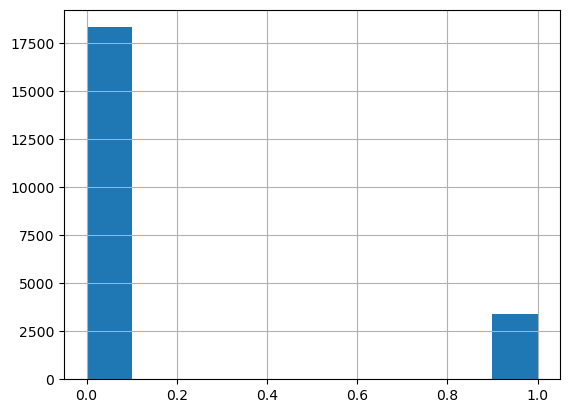

In [4]:
low_mass_central_df['quenching_vector'].hist()

In [5]:
galaxy_class_counts = low_mass_central_df.groupby("subID")["quenching_vector"].nunique()

# count galaxies with only one class vs. two classes
num_single_class_galaxies = (galaxy_class_counts == 1).sum()
num_two_class_galaxies = (galaxy_class_counts > 1).sum()

print(f"Number of galaxies with only one class: {num_single_class_galaxies}")
print(f"Number of galaxies with two classes: {num_two_class_galaxies}")

Number of galaxies with only one class: 1473
Number of galaxies with two classes: 1233


In [6]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import RobustScaler

# 'BHMass', 'BHCum_QM', 'Mhalo', 'overdens', and 'bulge' are the features wer are testing
low_mass_central_df = low_mass_central_df.drop(columns=["class", "BH_cumQM", "BH_cumRM", "global_SFRs", "avg_SFR","avg_gas_mass", "gas_mass", "Bfld", "veldisp", "BH_AGN"])
low_mass_central_df.duplicated()

15916    False
15917    False
15918    False
15919    False
15920    False
         ...  
63077    False
63078    False
63079    False
63080    False
63081    False
Length: 21677, dtype: bool

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END alpha=8.0, colsample_bytree=1.0, gamma=1.0, lambda=6.0, learning_rate=0.003, max_depth=2, min_child_weight=50, n_estimators=800, scale_pos_weight=1.0, subsample=0.7; total time=   0.4s
[CV] END alpha=8.0, colsample_bytree=1.0, gamma=1.0, lambda=6.0, learning_rate=0.003, max_depth=2, min_child_weight=50, n_estimators=800, scale_pos_weight=1.0, subsample=0.7; total time=   0.4s
[CV] END alpha=8.0, colsample_bytree=1.0, gamma=1.0, lambda=6.0, learning_rate=0.003, max_depth=2, min_child_weight=50, n_estimators=800, scale_pos_weight=1.0, subsample=0.7; total time=   0.4s
[CV] END alpha=8.0, colsample_bytree=1.0, gamma=1.0, lambda=6.0, learning_rate=0.003, max_depth=2, min_child_weight=50, n_estimators=800, scale_pos_weight=1.0, subsample=0.7; total time=   0.5s
[CV] END alpha=6.0, colsample_bytree=1.0, gamma=0.8, lambda=8.0, learning_rate=0.003, max_depth=2, min_child_weight=50, n_estimators=700, scale_pos_weight=1.0, sub

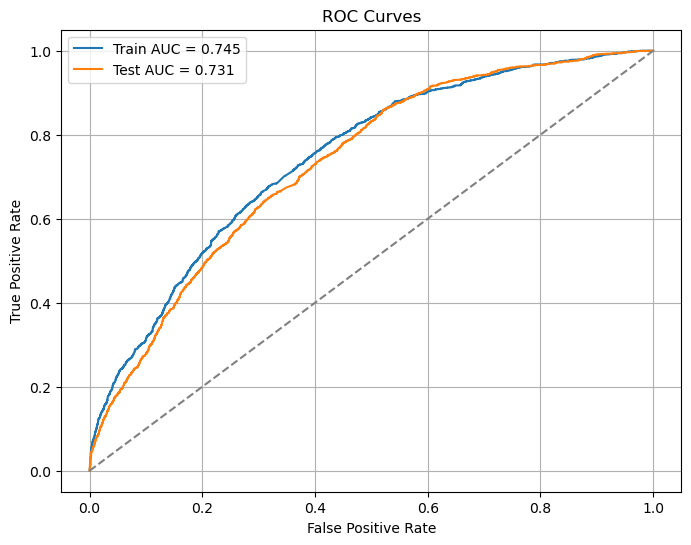

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END alpha=7.0, colsample_bytree=1.0, gamma=0.6, lambda=8.0, learning_rate=0.003, max_depth=2, min_child_weight=50, n_estimators=800, scale_pos_weight=1.0, subsample=0.7; total time=   0.4s
[CV] END alpha=7.0, colsample_bytree=1.0, gamma=0.6, lambda=8.0, learning_rate=0.003, max_depth=2, min_child_weight=50, n_estimators=800, scale_pos_weight=1.0, subsample=0.7; total time=   0.5s[CV] END alpha=7.0, colsample_bytree=1.0, gamma=0.6, lambda=8.0, learning_rate=0.003, max_depth=2, min_child_weight=50, n_estimators=800, scale_pos_weight=1.0, subsample=0.7; total time=   0.5s

[CV] END alpha=7.0, colsample_bytree=1.0, gamma=0.6, lambda=8.0, learning_rate=0.003, max_depth=2, min_child_weight=50, n_estimators=800, scale_pos_weight=1.0, subsample=0.7; total time=   0.5s
[CV] END alpha=7.0, colsample_bytree=1.0, gamma=0.6, lambda=8.0, learning_rate=0.003, max_depth=2, min_child_weight=50, n_estimators=800, scale_pos_weight=1.0, sub

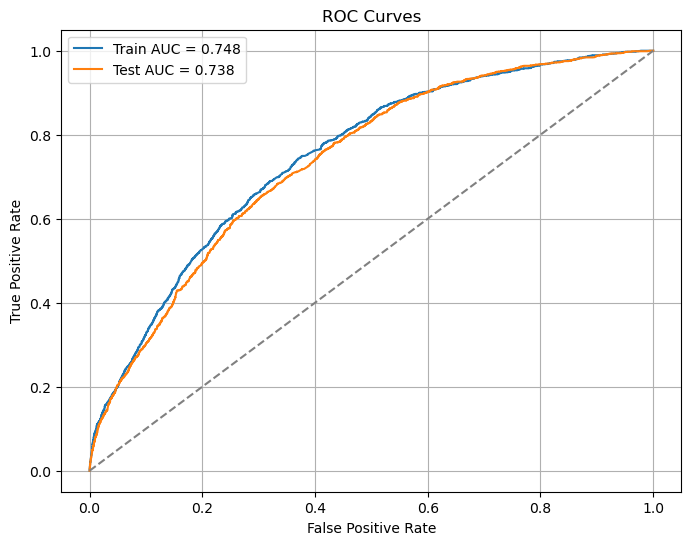

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END alpha=7.0, colsample_bytree=1.0, gamma=1.0, lambda=8.0, learning_rate=0.003, max_depth=2, min_child_weight=50, n_estimators=800, scale_pos_weight=1.0, subsample=0.6; total time=   0.5s
[CV] END alpha=7.0, colsample_bytree=1.0, gamma=1.0, lambda=8.0, learning_rate=0.003, max_depth=2, min_child_weight=50, n_estimators=800, scale_pos_weight=1.0, subsample=0.6; total time=   0.5s
[CV] END alpha=7.0, colsample_bytree=1.0, gamma=1.0, lambda=8.0, learning_rate=0.003, max_depth=2, min_child_weight=50, n_estimators=800, scale_pos_weight=1.0, subsample=0.6; total time=   0.5s
[CV] END alpha=7.0, colsample_bytree=1.0, gamma=1.0, lambda=8.0, learning_rate=0.003, max_depth=2, min_child_weight=50, n_estimators=800, scale_pos_weight=1.0, subsample=0.6; total time=   0.5s
[CV] END alpha=7.0, colsample_bytree=1.0, gamma=1.0, lambda=6.0, learning_rate=0.003, max_depth=2, min_child_weight=60, n_estimators=800, scale_pos_weight=1.0, sub

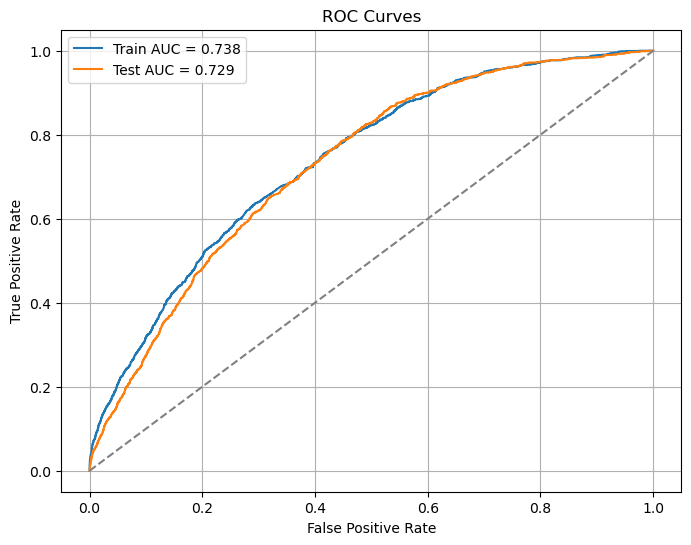

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END alpha=6.0, colsample_bytree=1.0, gamma=0.8, lambda=7.0, learning_rate=0.003, max_depth=2, min_child_weight=60, n_estimators=800, scale_pos_weight=1.0, subsample=0.7; total time=   0.4s
[CV] END alpha=6.0, colsample_bytree=1.0, gamma=0.8, lambda=7.0, learning_rate=0.003, max_depth=2, min_child_weight=60, n_estimators=800, scale_pos_weight=1.0, subsample=0.7; total time=   0.5s
[CV] END alpha=6.0, colsample_bytree=1.0, gamma=0.8, lambda=7.0, learning_rate=0.003, max_depth=2, min_child_weight=60, n_estimators=800, scale_pos_weight=1.0, subsample=0.7; total time=   0.5s
[CV] END alpha=6.0, colsample_bytree=1.0, gamma=0.8, lambda=7.0, learning_rate=0.003, max_depth=2, min_child_weight=60, n_estimators=800, scale_pos_weight=1.0, subsample=0.7; total time=   0.5s
[CV] END alpha=6.0, colsample_bytree=1.0, gamma=0.8, lambda=7.0, learning_rate=0.003, max_depth=2, min_child_weight=60, n_estimators=800, scale_pos_weight=1.0, sub

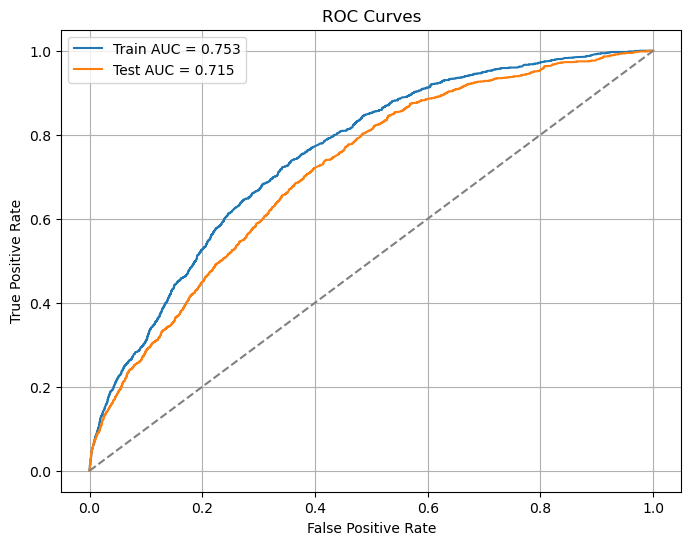

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END alpha=7.0, colsample_bytree=1.0, gamma=1.0, lambda=6.0, learning_rate=0.003, max_depth=2, min_child_weight=50, n_estimators=700, scale_pos_weight=1.0, subsample=0.7; total time=   0.4s
[CV] END alpha=7.0, colsample_bytree=1.0, gamma=1.0, lambda=6.0, learning_rate=0.003, max_depth=2, min_child_weight=50, n_estimators=700, scale_pos_weight=1.0, subsample=0.7; total time=   0.4s
[CV] END alpha=7.0, colsample_bytree=1.0, gamma=1.0, lambda=6.0, learning_rate=0.003, max_depth=2, min_child_weight=50, n_estimators=700, scale_pos_weight=1.0, subsample=0.7; total time=   0.4s
[CV] END alpha=7.0, colsample_bytree=1.0, gamma=1.0, lambda=6.0, learning_rate=0.003, max_depth=2, min_child_weight=50, n_estimators=700, scale_pos_weight=1.0, subsample=0.7; total time=   0.4s
[CV] END alpha=7.0, colsample_bytree=1.0, gamma=1.0, lambda=6.0, learning_rate=0.003, max_depth=2, min_child_weight=50, n_estimators=700, scale_pos_weight=1.0, sub

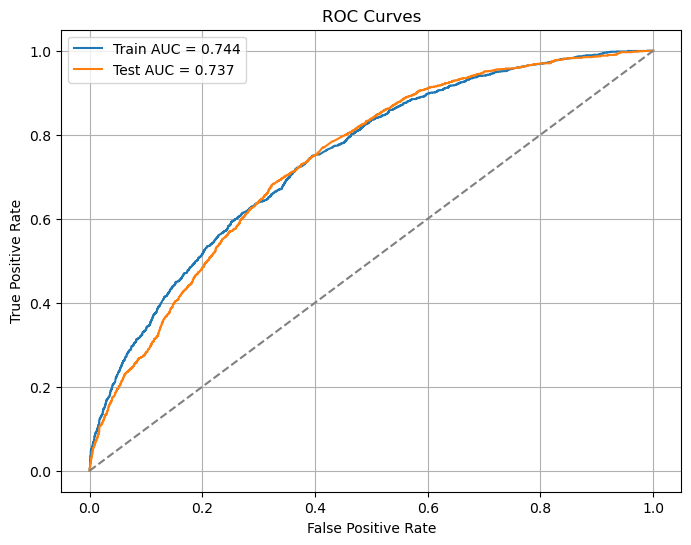

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END alpha=8.0, colsample_bytree=1.0, gamma=1.0, lambda=6.0, learning_rate=0.003, max_depth=2, min_child_weight=40, n_estimators=700, scale_pos_weight=1.0, subsample=0.7; total time=   0.4s
[CV] END alpha=8.0, colsample_bytree=1.0, gamma=1.0, lambda=6.0, learning_rate=0.003, max_depth=2, min_child_weight=40, n_estimators=700, scale_pos_weight=1.0, subsample=0.7; total time=   0.4s
[CV] END alpha=8.0, colsample_bytree=1.0, gamma=1.0, lambda=6.0, learning_rate=0.003, max_depth=2, min_child_weight=40, n_estimators=700, scale_pos_weight=1.0, subsample=0.7; total time=   0.4s
[CV] END alpha=8.0, colsample_bytree=1.0, gamma=1.0, lambda=6.0, learning_rate=0.003, max_depth=2, min_child_weight=40, n_estimators=700, scale_pos_weight=1.0, subsample=0.7; total time=   0.4s
[CV] END alpha=8.0, colsample_bytree=1.0, gamma=1.0, lambda=6.0, learning_rate=0.003, max_depth=2, min_child_weight=40, n_estimators=700, scale_pos_weight=1.0, sub

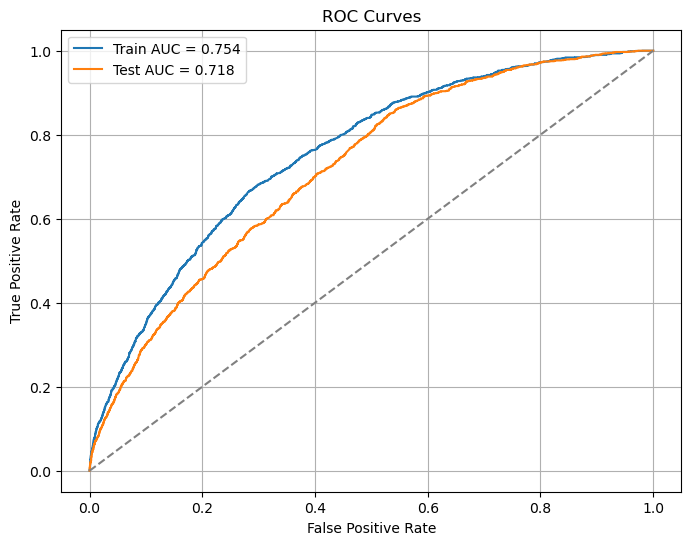

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END alpha=8.0, colsample_bytree=1.0, gamma=0.6, lambda=7.0, learning_rate=0.003, max_depth=2, min_child_weight=60, n_estimators=800, scale_pos_weight=1.0, subsample=0.6; total time=   0.5s
[CV] END alpha=8.0, colsample_bytree=1.0, gamma=0.6, lambda=7.0, learning_rate=0.003, max_depth=2, min_child_weight=60, n_estimators=800, scale_pos_weight=1.0, subsample=0.6; total time=   0.5s[CV] END alpha=8.0, colsample_bytree=1.0, gamma=0.6, lambda=7.0, learning_rate=0.003, max_depth=2, min_child_weight=60, n_estimators=800, scale_pos_weight=1.0, subsample=0.6; total time=   0.5s

[CV] END alpha=8.0, colsample_bytree=1.0, gamma=0.6, lambda=7.0, learning_rate=0.003, max_depth=2, min_child_weight=60, n_estimators=800, scale_pos_weight=1.0, subsample=0.6; total time=   0.5s
[CV] END alpha=7.0, colsample_bytree=1.0, gamma=0.6, lambda=8.0, learning_rate=0.003, max_depth=2, min_child_weight=60, n_estimators=700, scale_pos_weight=1.0, sub

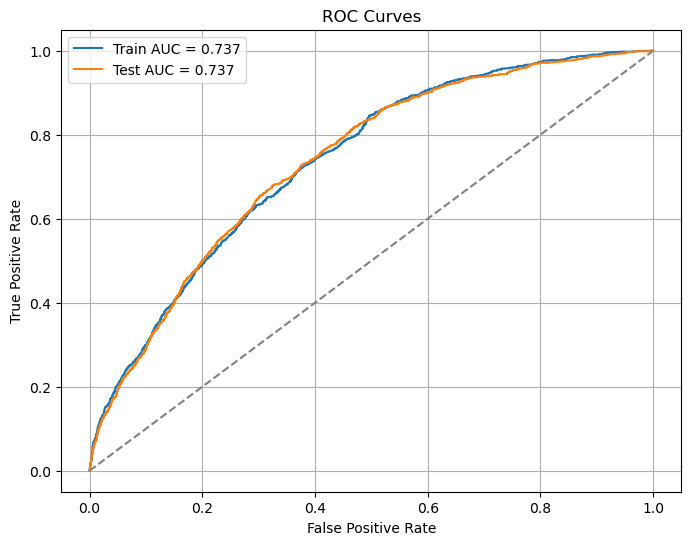

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END alpha=6.0, colsample_bytree=1.0, gamma=1.0, lambda=8.0, learning_rate=0.003, max_depth=2, min_child_weight=40, n_estimators=700, scale_pos_weight=1.0, subsample=0.7; total time=   0.4s
[CV] END alpha=6.0, colsample_bytree=1.0, gamma=1.0, lambda=8.0, learning_rate=0.003, max_depth=2, min_child_weight=40, n_estimators=700, scale_pos_weight=1.0, subsample=0.7; total time=   0.4s
[CV] END alpha=6.0, colsample_bytree=1.0, gamma=1.0, lambda=8.0, learning_rate=0.003, max_depth=2, min_child_weight=40, n_estimators=700, scale_pos_weight=1.0, subsample=0.7; total time=   0.5s
[CV] END alpha=6.0, colsample_bytree=1.0, gamma=1.0, lambda=8.0, learning_rate=0.003, max_depth=2, min_child_weight=40, n_estimators=700, scale_pos_weight=1.0, subsample=0.7; total time=   0.5s
[CV] END alpha=6.0, colsample_bytree=1.0, gamma=1.0, lambda=8.0, learning_rate=0.003, max_depth=2, min_child_weight=40, n_estimators=700, scale_pos_weight=1.0, sub

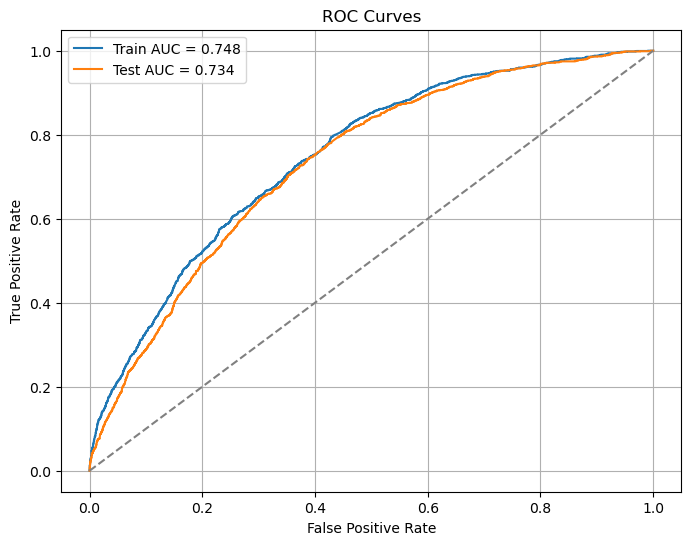

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END alpha=6.0, colsample_bytree=1.0, gamma=0.6, lambda=6.0, learning_rate=0.003, max_depth=2, min_child_weight=40, n_estimators=700, scale_pos_weight=1.0, subsample=0.6; total time=   0.4s
[CV] END alpha=6.0, colsample_bytree=1.0, gamma=0.6, lambda=6.0, learning_rate=0.003, max_depth=2, min_child_weight=40, n_estimators=700, scale_pos_weight=1.0, subsample=0.6; total time=   0.4s
[CV] END alpha=6.0, colsample_bytree=1.0, gamma=0.6, lambda=6.0, learning_rate=0.003, max_depth=2, min_child_weight=40, n_estimators=700, scale_pos_weight=1.0, subsample=0.6; total time=   0.4s
[CV] END alpha=6.0, colsample_bytree=1.0, gamma=0.6, lambda=6.0, learning_rate=0.003, max_depth=2, min_child_weight=40, n_estimators=700, scale_pos_weight=1.0, subsample=0.6; total time=   0.4s
[CV] END alpha=6.0, colsample_bytree=1.0, gamma=0.6, lambda=6.0, learning_rate=0.003, max_depth=2, min_child_weight=40, n_estimators=700, scale_pos_weight=1.0, sub

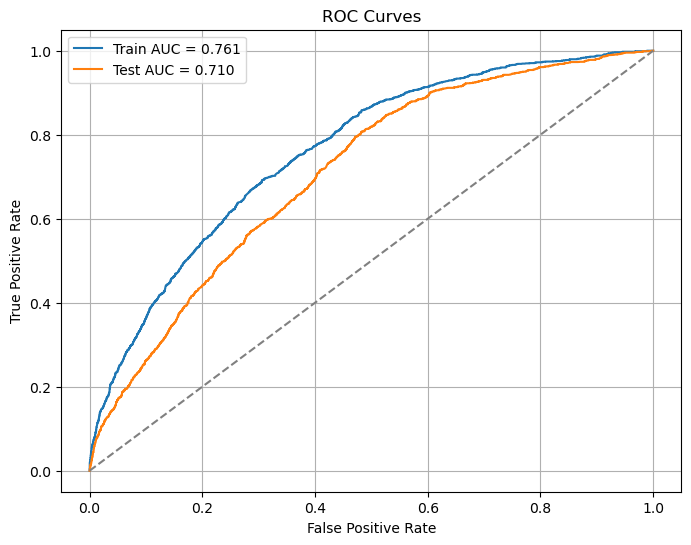

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END alpha=8.0, colsample_bytree=1.0, gamma=0.8, lambda=7.0, learning_rate=0.003, max_depth=2, min_child_weight=50, n_estimators=700, scale_pos_weight=1.0, subsample=0.6; total time=   0.4s
[CV] END alpha=8.0, colsample_bytree=1.0, gamma=0.8, lambda=7.0, learning_rate=0.003, max_depth=2, min_child_weight=50, n_estimators=700, scale_pos_weight=1.0, subsample=0.6; total time=   0.4s
[CV] END alpha=8.0, colsample_bytree=1.0, gamma=0.8, lambda=7.0, learning_rate=0.003, max_depth=2, min_child_weight=50, n_estimators=700, scale_pos_weight=1.0, subsample=0.6; total time=   0.4s
[CV] END alpha=8.0, colsample_bytree=1.0, gamma=0.8, lambda=7.0, learning_rate=0.003, max_depth=2, min_child_weight=50, n_estimators=700, scale_pos_weight=1.0, subsample=0.6; total time=   0.4s
[CV] END alpha=8.0, colsample_bytree=1.0, gamma=0.8, lambda=7.0, learning_rate=0.003, max_depth=2, min_child_weight=50, n_estimators=700, scale_pos_weight=1.0, sub

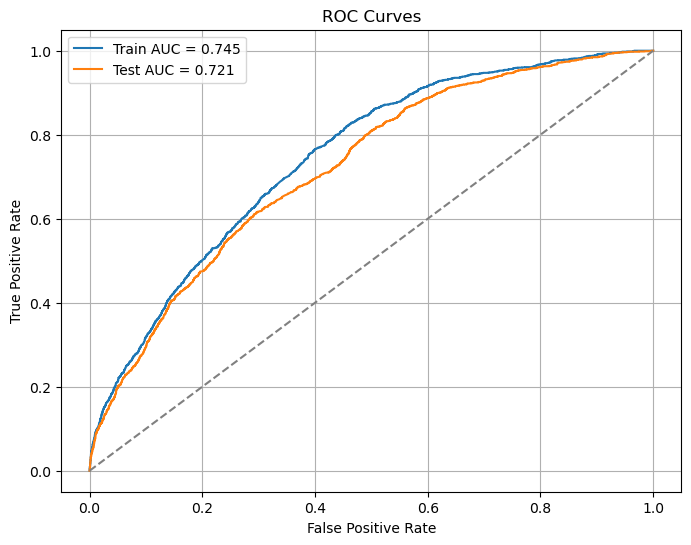


Average AUC over 10 runs:
Train AUC: Mean = 0.7474, Std = 0.0069
Test AUC:  Mean = 0.7271, Std = 0.0096
Train F1: Mean = 0.0000, Std = 0.0000
Test F1:  Mean = 0.0000, Std = 0.0000


In [7]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score

# splitting galaxies into test/train based on subID
unique_galaxies = np.unique(low_mass_central_df['subID'])

train_aucs = []
test_aucs = []
feature_importances_list = []
feature_names = None
train_f1s = []
test_f1s = []


for seed in range(10):
    train_galaxies, test_galaxies = train_test_split(unique_galaxies, test_size=0.5, random_state=seed)

    train_data = low_mass_central_df[low_mass_central_df['subID'].isin(train_galaxies)]
    test_data = low_mass_central_df[low_mass_central_df['subID'].isin(test_galaxies)]

    X_train, y_train = train_data.drop(columns=['quenching_vector', 'subID']), train_data['quenching_vector']
    X_test, y_test = test_data.drop(columns=['quenching_vector', 'subID']), test_data['quenching_vector']

    if feature_names is None:
        feature_names = X_train.columns.tolist()
    # scaling
    scaler = RobustScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

    xgb_clf = xgb.XGBClassifier(random_state=seed, objective='binary:logistic')

    param_grid_xgb = {
    'n_estimators': [700, 800],
    'max_depth': [2],
    'learning_rate': [0.003],
    'subsample': [0.6, 0.7],
    'colsample_bytree': [1.0],
    'min_child_weight': [40, 50, 60],
    'gamma': [0.6, 0.8, 1.0],
    'lambda': [6.0, 7.0, 8.0],     # L2 regularization
    'alpha': [6.0, 7.0, 8.0],      # L1 regularization
    'scale_pos_weight': [1.0]    
    }


    random_search_xgb = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_grid_xgb,
    n_iter=10,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1, 
    random_state=seed,
    verbose=2,
    )

    random_search_xgb.fit(X_train_scaled, y_train)

    best_xgb = random_search_xgb.best_estimator_

    y_train_prob = best_xgb.predict_proba(X_train_scaled)[:, 1]
    y_test_prob = best_xgb.predict_proba(X_test_scaled)[:, 1]

    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
    fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)

    # ROC curves
    plt.figure(figsize=(8,6))
    plt.plot(fpr_train, tpr_train, label=f'Train AUC = {roc_auc_score(y_train, y_train_prob):.3f}')
    plt.plot(fpr_test, tpr_test, label=f'Test AUC = {roc_auc_score(y_test, y_test_prob):.3f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # aucs and feature importance
    train_auc = roc_auc_score(y_train, y_train_prob)
    test_auc = roc_auc_score(y_test, y_test_prob)
    feature_importances_list.append(best_xgb.feature_importances_)
    
    train_aucs.append(train_auc)
    test_aucs.append(test_auc)


    y_train_pred = best_xgb.predict(X_train_scaled)
    y_test_pred = best_xgb.predict(X_test_scaled)

    # f1 scores
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    train_f1s.append(train_f1)
    test_f1s.append(test_f1)
    
print("\nAverage AUC over 10 runs:")
print(f"Train AUC: Mean = {np.mean(train_aucs):.4f}, Std = {np.std(train_aucs):.4f}")
print(f"Test AUC:  Mean = {np.mean(test_aucs):.4f}, Std = {np.std(test_aucs):.4f}")
print(f"Train F1: Mean = {np.mean(train_f1s):.4f}, Std = {np.std(train_f1s):.4f}")
print(f"Test F1:  Mean = {np.mean(test_f1s):.4f}, Std = {np.std(test_f1s):.4f}")


=== Average Feature Importances ===
      Feature  Mean Importance   Std Dev
6       bulge         0.182211  0.026164
3      BHMass         0.166933  0.037591
1  avg_s_mass         0.159919  0.018499
0   bin_radii         0.145476  0.025664
4       Mhalo         0.140338  0.026399
2      s_mass         0.113330  0.059610
5    overdens         0.091793  0.021688


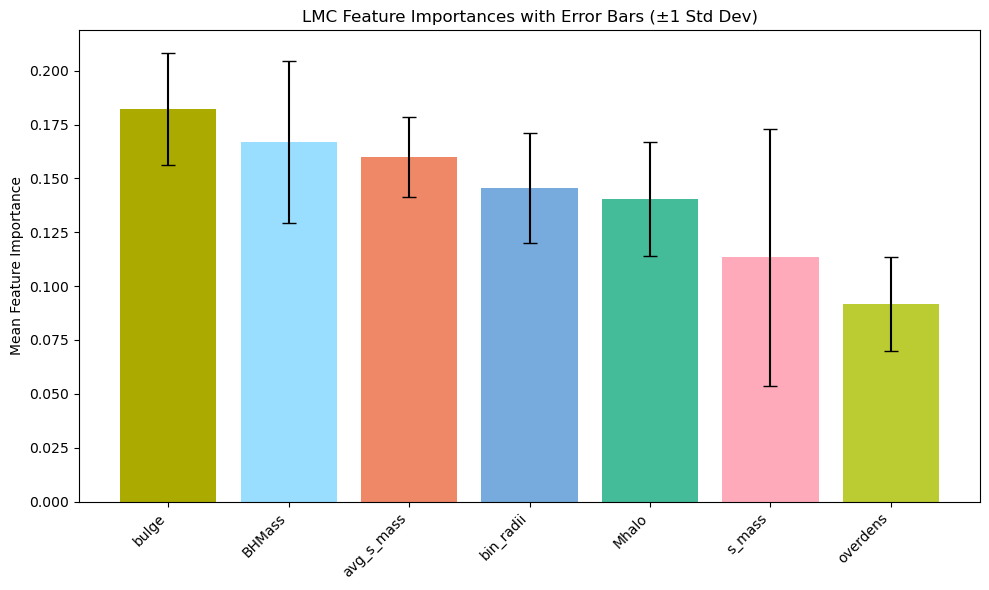

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
feature_colors = {
    'bin_radii': '#77AADD',
    'avg_s_mass': '#EE8866',
    's_mass': '#FFAABB',
    'BHMass': '#99DDFF',
    'Mhalo': '#44BB99',
    'overdens': '#BBCC33',
    'bulge': '#AAAA00',
    'BH_AGN': '#DDDDDD',
}

# importances + stds across 10 runs
importances_array = np.array(feature_importances_list)
importance_means = np.mean(importances_array, axis=0)
importance_stds = np.std(importances_array, axis=0)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean Importance': importance_means,
    'Std Dev': importance_stds
}).sort_values(by='Mean Importance', ascending=False)

print("\n=== Average Feature Importances ===")
print(importance_df)

colors = [feature_colors[feat] for feat in importance_df['Feature']]
# Plot
plt.figure(figsize=(10, 6))
plt.bar(importance_df['Feature'], importance_df['Mean Importance'], yerr=importance_df['Std Dev'], capsize=5, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Mean Feature Importance")
plt.title("LMC Feature Importances with Error Bars (±1 Std Dev)")
plt.tight_layout()
plt.show()

In [9]:
import os
# Define your directory and file name
directory = 'xg_classification_outputs'
filename = 'lmc_xg_quenching.csv'
filepath = os.path.join(directory, filename)

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the DataFrame
importance_df.to_csv(filepath, index=False)

print(f'DataFrame saved to {filepath}')

DataFrame saved to xg_classification_outputs/lmc_xg_quenching.csv


In [10]:
train_mean = round(np.mean(train_aucs), 2)
test_mean = round(np.mean(test_aucs), 2)
print(train_mean)
df = pd.DataFrame({
    'Train AUC': [train_mean],
    'Test AUC': [test_mean]
})

print(df)
import os
# Define your directory and file name
directory = 'xg_classification_outputs'
filename = 'lmc_xg_quenching_auc.csv'
filepath = os.path.join(directory, filename)

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the DataFrame
df.to_csv(filepath, index=False)

print(f'DataFrame saved to {filepath}')

0.75
   Train AUC  Test AUC
0       0.75      0.73
DataFrame saved to xg_classification_outputs/lmc_xg_quenching_auc.csv
